In [87]:
import os
os.chdir("")

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [89]:
import duckdb
con = duckdb.connect("ocean.duckdb")
con.sql("SHOW TABLES").df()

,name
0,chl_dineof
1,chl_erd
2,cuti
3,glider
4,kelp
5,pdo
6,rain
7,reef
8,sst


In [90]:
con.sql("CALL start_ui()")

┌──────────────────────────────────────┐
│                result                │
│               varchar                │
├──────────────────────────────────────┤
│ UI started at http://localhost:4213/ │
└──────────────────────────────────────┘

---

renaming all the datasets so that it will be easier to access and run jupyter notebooks on it

__List of datasets:__
* kelp
* reef
* cuti
* glider
* pdo
* sst
* rain
* chl_dineof
* chl_erdap


---

In [91]:
kelp = con.execute("SELECT * FROM 'kelp'").df()

In [92]:
reef = con.execute("SELECT * FROM 'reef'").df()

In [93]:
cuti = con.execute("SELECT * FROM 'cuti'").df()

In [94]:
glider = con.execute("SELECT * FROM 'glider'").df()

In [95]:
pdo = con.execute("SELECT * FROM 'pdo'").df()

In [96]:
sst =  con.execute("SELECT * FROM 'sst'").df()

In [97]:
rain = con.execute("SELECT * FROM 'rain'").df()

In [98]:
chl_dineof = con.execute("SELECT * FROM 'chl_dineof'").df()

In [99]:
chl_erd = con.execute("SELECT * FROM 'chl_erd'").df()

---
reviewing the datasets and cleaning the data
---


--- 
Within the dataset I want to return all the urchin data and the kelp individual. There are 4 types of urchins
Sea urchins:

* Purple Urchin Scientific name: Strongylocentrotus purpuratus
* Red Urchin - Mesocentrotus franciscanus
* Crowned Sea Urchin - Centrostephanus coronatus
* White Sea Urchin : Lytechinus pictus

within the analysis notebook - I could tell that the primary urchin population is the purple and red sea urchin. 


In [100]:
reef

,site,transect,date,year,month,species,common_name,density,percent_cover,wet_biomass
0,NAPL,3,2008-01-10,2008,1,Abietinaria spp.,Coarse Sea Fir Hydroid,NaN,0.00,0.000000
1,NAPL,3,2008-01-10,2008,1,Alloclinus holderi,Island Kelpfish,0.00,NaN,0.000000
2,NAPL,3,2008-01-10,2008,1,Astrangia haimei,Aggregating cup Coral,NaN,1.25,0.059768
3,NAPL,3,2008-01-10,2008,1,Patiria miniata,Bat Star,4.55,NaN,232.522842
4,NAPL,3,2008-01-10,2008,1,Amphiroa beauvoisii,-99999,NaN,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...
91155,MOHK,2,2026-02-25,2026,2,Cribrinopsis albopunctata,Whit-Spotted Rose Anemone,0.00,NaN,0.000000
91156,MOHK,2,2026-02-25,2026,2,Unidentified Didemnidae spp.,Unidentified compound tunicate,NaN,0.00,0.000000
91157,MOHK,2,2026-02-25,2026,2,Ulva spp.,Sea Lettuce,NaN,0.00,0.000000
91158,MOHK,2,2026-02-25,2026,2,Watersipora subatra,-99999,NaN,0.00,0.000000


In [101]:
all_urchin = reef[(reef['species'] == 'Strongylocentrotus purpuratus') | (reef['species'] == 'Mesocentrotus franciscanus') | (reef['species'] == 'Centrostephanus coronatus') | (reef['species'] == 'Lytechinus pictus')]
urchin = reef[(reef['species'] == 'Strongylocentrotus purpuratus') | (reef['species'] == 'Mesocentrotus franciscanus')]

In [102]:
urchin

,site,transect,date,year,month,species,common_name,density,percent_cover,wet_biomass
187,NAPL,3,2008-01-10,2008,1,Mesocentrotus franciscanus,Red Urchin,8.000000,NaN,852.187557
193,NAPL,3,2008-01-10,2008,1,Strongylocentrotus purpuratus,Purple Urchin,48.166667,NaN,859.947953
402,MOHK,2,2008-01-17,2008,1,Mesocentrotus franciscanus,Red Urchin,0.333333,NaN,49.527873
408,MOHK,2,2008-01-17,2008,1,Strongylocentrotus purpuratus,Purple Urchin,8.500000,NaN,369.427782
617,AQUE,4,2008-01-30,2008,1,Mesocentrotus franciscanus,Red Urchin,0.000000,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...
90708,NAPL,3,2026-02-24,2026,2,Strongylocentrotus purpuratus,Purple Urchin,1.833333,NaN,54.030970
90917,CARP,7,2026-02-25,2026,2,Mesocentrotus franciscanus,Red Urchin,2.833333,NaN,413.994296
90923,CARP,7,2026-02-25,2026,2,Strongylocentrotus purpuratus,Purple Urchin,3.166667,NaN,63.812761
91132,MOHK,2,2026-02-25,2026,2,Mesocentrotus franciscanus,Red Urchin,0.000000,NaN,0.000000


In [103]:
urchin.value_counts("species")

species
Mesocentrotus franciscanus       424
Strongylocentrotus purpuratus    424
Name: count, dtype: int64

In [104]:
all_urchin.value_counts("species")

species
Centrostephanus coronatus        424
Lytechinus pictus                424
Mesocentrotus franciscanus       424
Strongylocentrotus purpuratus    424
Name: count, dtype: int64

What this taught me is that each value is being accounted for in the survey - so now I need to look at the density, precent_cover, and wet biomass


In [105]:
urchin_density = urchin.groupby(['year', 'month', 'date', 'site', 'species']).agg({'density': 'mean'}).reset_index()

In [106]:
urchin_density[["year", "month", "date", "species"]]     

,year,month,date,species
0,2008,1,2008-01-10,Mesocentrotus franciscanus
1,2008,1,2008-01-10,Strongylocentrotus purpuratus
2,2008,1,2008-01-17,Mesocentrotus franciscanus
3,2008,1,2008-01-17,Strongylocentrotus purpuratus
4,2008,1,2008-01-30,Mesocentrotus franciscanus
...,...,...,...,...
843,2026,2,2026-02-24,Strongylocentrotus purpuratus
844,2026,2,2026-02-25,Mesocentrotus franciscanus
845,2026,2,2026-02-25,Strongylocentrotus purpuratus
846,2026,2,2026-02-25,Mesocentrotus franciscanus


In [107]:
# making it yearly quarter for the two speciesof urchins and then averaging the density for each quarter
urchin_density["yq"] = urchin_density["date"].dt.to_period("Q")
urchin_quarterly = urchin_density.groupby(["yq", "species"])["density"].mean().reset_index()

In [108]:
urchin_quarterly

,yq,species,density
0,2008Q1,Mesocentrotus franciscanus,2.333333
1,2008Q1,Strongylocentrotus purpuratus,16.854167
2,2008Q2,Mesocentrotus franciscanus,1.583333
3,2008Q2,Strongylocentrotus purpuratus,17.638889
4,2008Q3,Mesocentrotus franciscanus,1.750000
...,...,...,...
139,2025Q3,Strongylocentrotus purpuratus,2.300000
140,2025Q4,Mesocentrotus franciscanus,0.566667
141,2025Q4,Strongylocentrotus purpuratus,1.666667
142,2026Q1,Mesocentrotus franciscanus,0.700000


<Axes: title={'center': 'Quarterly Urchin Density by Species'}, xlabel='yq'>

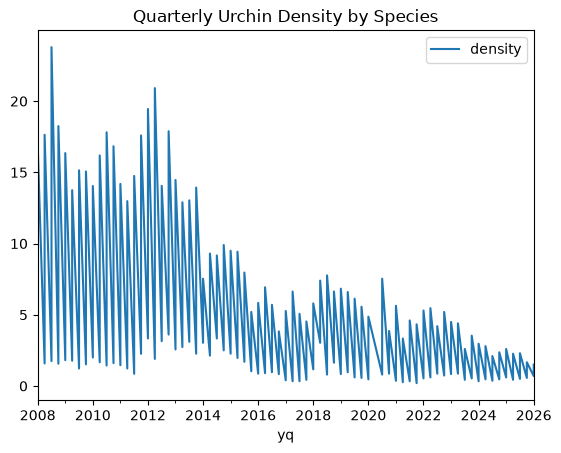

In [109]:
urchin_quarterly.plot(x="yq", y="density", kind="line", title="Quarterly Urchin Density by Species")

Text(0, 0.5, 'Density')

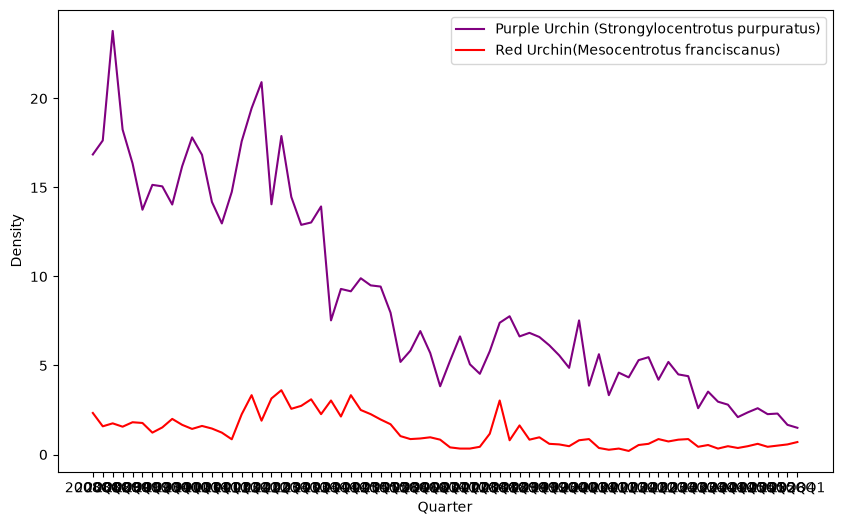

In [110]:
# name the data

purple_urchin = urchin_quarterly[urchin_quarterly["species"] == "Strongylocentrotus purpuratus"]
red_urchin = urchin_quarterly[urchin_quarterly["species"] == "Mesocentrotus franciscanus"]

#generate the plot 
plt.figure(figsize=(10, 6))

# create the line plot with labels and colors
plt.plot(purple_urchin["yq"].astype(str), purple_urchin["density"], label="Purple Urchin (Strongylocentrotus purpuratus)", color = "purple")
plt.plot(red_urchin["yq"].astype(str), red_urchin["density"], label="Red Urchin(Mesocentrotus franciscanus)", color = "red")

plt.legend()
plt.xlabel("Quarter")
plt.ylabel("Density")


---
Checking the kelp species for the reef dataset


In [111]:
kelp_from_reef = reef[(reef['species'] == 'Macrocystis pyrifera')|(reef['species'] == 'Nereocystis luetkeana') | (reef['species'] == 'Egregia menziesii') | (reef['species'] == 'Pterygophora californica')]

In [112]:
kelp_from_reef.value_counts("species")

species
Egregia menziesii           424
Macrocystis pyrifera        424
Pterygophora californica    424
Name: count, dtype: int64

In [113]:
kelp_from_reef.groupby(['year', 'month', 'date', 'site', 'species', 'common_name']).agg({'density': 'mean'}).reset_index()

,year,month,date,site,species,common_name,density
0,2008,1,2008-01-10,NAPL,Egregia menziesii,Feather Boa Kelp,0.000000
1,2008,1,2008-01-10,NAPL,Macrocystis pyrifera,Giant Kelp,0.000000
2,2008,1,2008-01-10,NAPL,Pterygophora californica,Palm Kelp,0.000000
3,2008,1,2008-01-17,MOHK,Egregia menziesii,Feather Boa Kelp,0.000000
4,2008,1,2008-01-17,MOHK,Macrocystis pyrifera,Giant Kelp,5.733333
...,...,...,...,...,...,...,...
1267,2026,2,2026-02-25,CARP,Macrocystis pyrifera,Giant Kelp,0.000000
1268,2026,2,2026-02-25,CARP,Pterygophora californica,Palm Kelp,1.558333
1269,2026,2,2026-02-25,MOHK,Egregia menziesii,Feather Boa Kelp,0.000000
1270,2026,2,2026-02-25,MOHK,Macrocystis pyrifera,Giant Kelp,0.000000


In [114]:
kelp_from_reef['yq']= kelp_from_reef['date'].dt.to_period('Q')
kelp_quarterly = kelp_from_reef.groupby(['yq', 'species'])['density'].mean().reset_index()

Text(0, 0.5, 'Density')

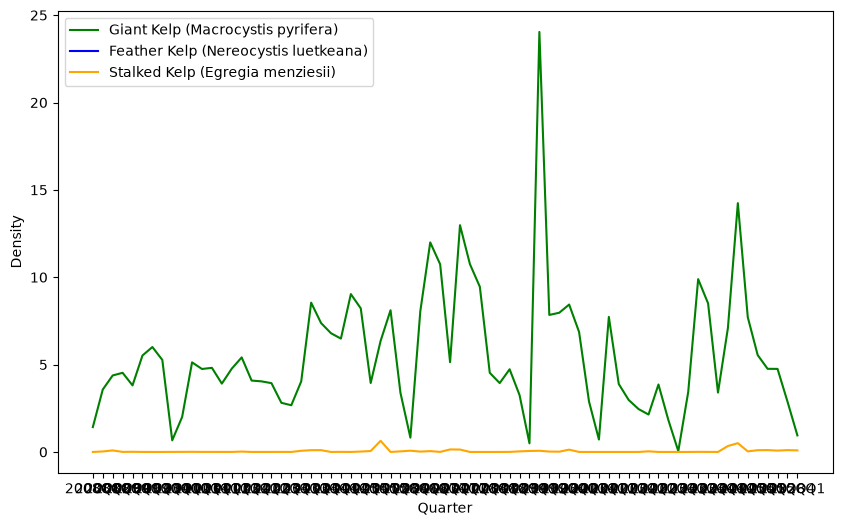

In [115]:
# want to plot it like the urchin density plot, so need to separate the species into different dataframes

giant_kelp = kelp_quarterly[kelp_quarterly['species'] == 'Macrocystis pyrifera']
feather_kelp = kelp_quarterly[kelp_quarterly['species'] == 'Nereocystis luetkeana']
stalked_kelp = kelp_quarterly[kelp_quarterly['species'] == 'Egregia menziesii']

plt.figure(figsize=(10, 6))

plt.plot(giant_kelp['yq'].astype(str), giant_kelp['density'], label='Giant Kelp (Macrocystis pyrifera)', color='green')
plt.plot(feather_kelp['yq'].astype(str), feather_kelp['density'], label='Feather Kelp (Nereocystis luetkeana)', color='blue')
plt.plot(stalked_kelp['yq'].astype(str), stalked_kelp['density'], label='Stalked Kelp (Egregia menziesii)', color='orange')

plt.legend()
plt.xlabel('Quarter')
plt.ylabel('Density')


---
From this plot I can observe that the primary kelp will be the Giant kelp - however let me comfirm 

In [116]:
kelp_search = reef[reef['species'] =='kelp']

In [117]:
search_kelp = 'kelp'
results_kelp_reef = reef[reef['common_name'].str.contains(search_kelp, case=False, na=False)]

In [118]:
results_kelp_reef.value_counts('common_name')

common_name
Island Kelpfish                                        424
Kelp Surfperch                                         424
Unidentifiable juvenile kelp - not a unique species    424
Crevice Kelpfish                                       424
Southern Palm Kelp                                     424
Feather Boa Kelp                                       424
Kelp Greenling                                         424
Giant Kelpfish                                         424
Giant Kelp                                             424
Kelp Bryozoan                                          424
Kelp Bass                                              424
Palm Kelp                                              424
Kelp Crab                                              424
Kelp Rockfish                                          424
Name: count, dtype: int64

---
From the list provided it is clear that some of them are fish, crabs, etc. So need to remove those from my list and then I want to check what the yearly averages are to see if I am missing a kelp that is influential


In [119]:
# 1. Define the explicit list of actual kelp species
true_kelp_species = [
    'Giant Kelp',
    'Palm Kelp',
    'Southern Palm Kelp',
    'Feather Boa Kelp', 
    'Unidentifiable juvenile kelp'
]

# 2. Filter your DataFrame to keep ONLY these true kelps
kelp_only_df = reef[reef['common_name'].isin(true_kelp_species)].copy()

# Verify your cleaned dataset
print(kelp_only_df['common_name'].value_counts())



common_name
Southern Palm Kelp    424
Feather Boa Kelp      424
Giant Kelp            424
Palm Kelp             424
Name: count, dtype: int64


In [120]:
yearly_kelp_means = kelp_only_df.groupby(['year', 'common_name']).agg({'density': 'mean'}).reset_index()

In [121]:
kelp_trends= yearly_kelp_means.pivot(index='year', columns='common_name', values='density')
print(kelp_trends)

common_name  Feather Boa Kelp  Giant Kelp  Palm Kelp  Southern Palm Kelp
year                                                                    
2008                 0.022005    3.337634   5.510677            0.000000
2009                 0.002734    5.150781   6.147005            0.000000
2010                 0.004297    3.136068   9.034505            0.000000
2011                 0.007323    4.746717   3.906692            0.000000
2012                 0.001071    3.815952   1.876429            0.000000
2013                 0.067292    5.658333   1.131667            0.000000
2014                 0.006875    7.633750   3.709167            0.000000
2015                 0.181042    5.448750   0.396875            0.000000
2016                 0.035625    7.901250   0.375000            0.008333
2017                 0.070208    9.579375   0.124167            0.000000
2018                 0.008958    4.115000   0.153333            0.000000
2019                 0.040208   10.085417   8.69791

Text(0, 0.5, 'Density')

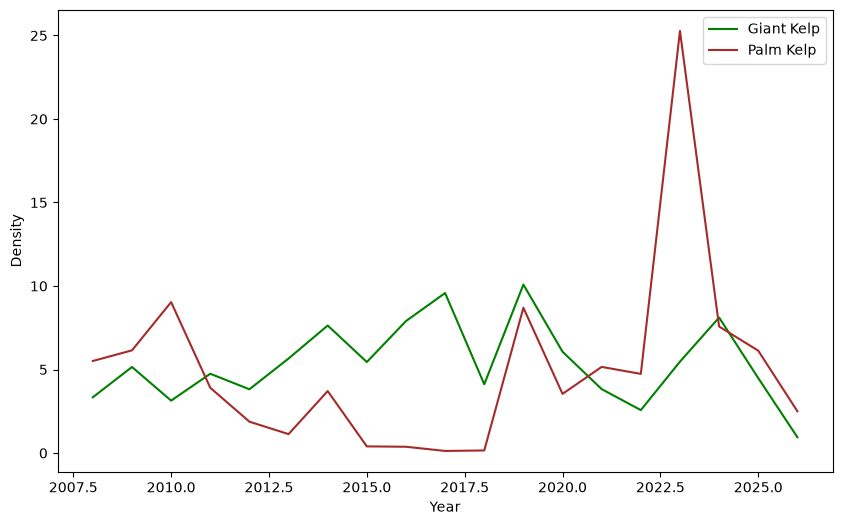

In [122]:
# looks like palm kelp still carries a lot of information, so lets try plotting giant kelp with palm kelp


plt.figure(figsize=(10, 6))

plt.plot(kelp_trends.index, kelp_trends['Giant Kelp'], label='Giant Kelp', color='green')
plt.plot(kelp_trends.index, kelp_trends['Palm Kelp'], label='Palm Kelp', color='brown')

plt.legend()
plt.xlabel('Year')
plt.ylabel('Density')

In [167]:
kelp_only_df["yq"] = kelp_only_df["date"].dt.to_period("Q")
palm_quarterly = kelp_only_df[kelp_only_df["common_name"] == "Palm Kelp"].groupby("yq")["density"].mean().reset_index()

Text(0, 0.5, 'Density')

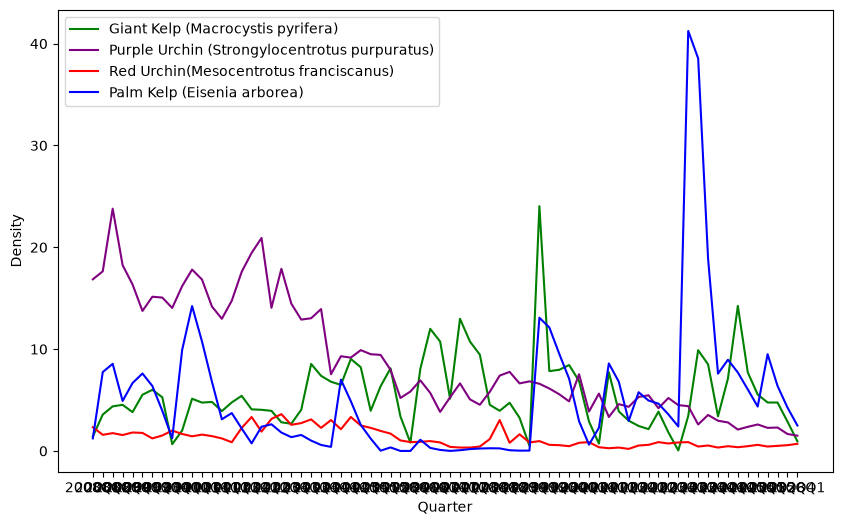

In [170]:
plt.figure(figsize=(10, 6))

plt.plot(giant_kelp['yq'].astype(str), giant_kelp['density'], label='Giant Kelp (Macrocystis pyrifera)', color='green')
plt.plot(purple_urchin["yq"].astype(str), purple_urchin["density"], label="Purple Urchin (Strongylocentrotus purpuratus)", color = "purple")
plt.plot(red_urchin["yq"].astype(str), red_urchin["density"], label="Red Urchin(Mesocentrotus franciscanus)", color = "red")
plt.plot(palm_quarterly['yq'].astype(str), palm_quarterly['density'], label='Palm Kelp (Eisenia arborea)', color='blue')

plt.legend()
plt.xlabel('Quarter')
plt.ylabel('Density')

--- 
Looking at how the Sea Surface temperatures are increasing - I have that one per pixel over coordinates from 2014- 2026


In [123]:
sst

,ts,lat,lon,sst_c
0,2018-01-01 09:00:00,33.69,-120.52,14.857
1,2018-01-01 09:00:00,33.69,-120.51,14.877
2,2018-01-01 09:00:00,33.69,-120.50,14.896
3,2018-01-01 09:00:00,33.69,-120.49,14.912
4,2018-01-01 09:00:00,33.69,-120.48,14.925
...,...,...,...,...
42632779,2026-07-31 09:00:00,34.51,-118.93,NaN
42632780,2026-07-31 09:00:00,34.51,-118.92,NaN
42632781,2026-07-31 09:00:00,34.51,-118.91,NaN
42632782,2026-07-31 09:00:00,34.51,-118.90,NaN


In [124]:
sst_average = sst.groupby([ 'ts', 'lat', 'lon']).agg({'sst_c': 'mean'}).reset_index()

In [125]:
sst_average_by_date = sst.groupby([ 'ts']).agg({'sst_c': 'mean'}).reset_index()

In [126]:
sst_average_by_date

,ts,sst_c
0,2018-01-01 09:00:00,15.555082
1,2018-01-02 09:00:00,15.761164
2,2018-01-03 09:00:00,15.908367
3,2018-01-04 09:00:00,15.982560
4,2018-01-05 09:00:00,15.888877
...,...,...
3127,2026-07-27 09:00:00,20.799821
3128,2026-07-28 09:00:00,20.667431
3129,2026-07-29 09:00:00,20.459232
3130,2026-07-30 09:00:00,20.489003


<Axes: title={'center': 'Average Sea Surface Temperature Over Time 2018 - 2026'}, xlabel='ts'>

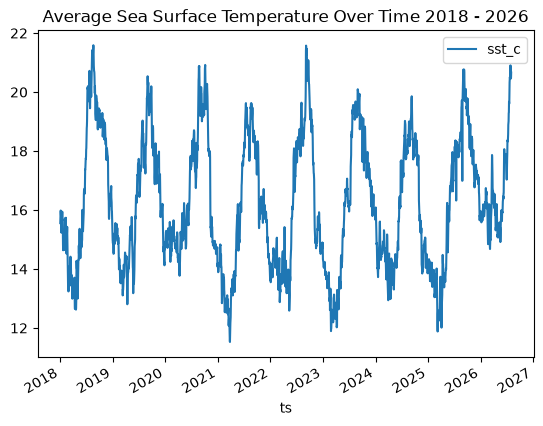

In [127]:
sst_average_by_date.plot(x="ts", y="sst_c", kind="line", title="Average Sea Surface Temperature Over Time 2018 - 2026")

In [128]:
sst_average_by_date["yq"] = sst_average_by_date["ts"].dt.to_period("Q")
sst_quarterly = sst_average_by_date.groupby("yq")["sst_c"].mean().reset_index()

<Axes: title={'center': 'Quarterly Average Sea Surface Temperature Over Time 2018 - 2026'}, xlabel='yq'>

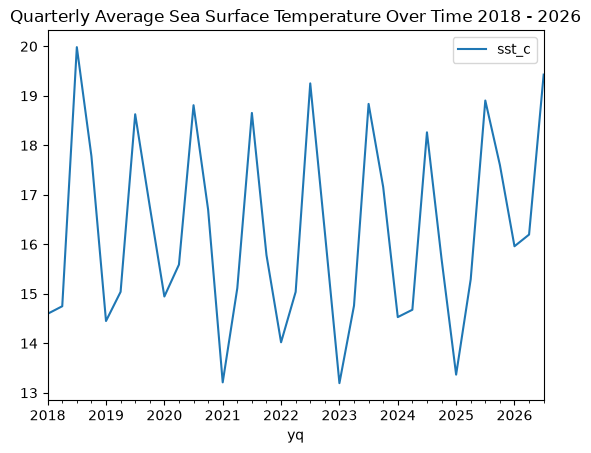

In [129]:
sst_quarterly.plot(x="yq", y="sst_c", kind="line", title="Quarterly Average Sea Surface Temperature Over Time 2018 - 2026")

---
Cuti - Upwelling index next 


In [130]:
cuti

,ts,lat,cuti
0,2018-01-01,33.0,-0.297
1,2018-01-01,34.0,-0.524
2,2018-01-01,35.0,-0.139
3,2018-01-02,33.0,-0.103
4,2018-01-02,34.0,-0.546
...,...,...,...
9427,2026-08-09,34.0,0.938
9428,2026-08-09,35.0,0.315
9429,2026-08-10,33.0,0.066
9430,2026-08-10,34.0,0.274


In [131]:
cuti_average_by_date = sst.groupby(['ts', 'lat'])
cuti_average_by_date = cuti.groupby(['ts']).agg({'cuti': 'mean'}).reset_index()

In [132]:
cuti_average_by_date

,ts,cuti
0,2018-01-01,-0.320000
1,2018-01-02,-0.157000
2,2018-01-03,-0.312000
3,2018-01-04,-0.235667
4,2018-01-05,-0.391000
...,...,...
3139,2026-08-06,0.002333
3140,2026-08-07,0.011333
3141,2026-08-08,0.109000
3142,2026-08-09,0.679000


<Axes: title={'center': 'Upwelling Index Over Time 2018 - 2026'}, xlabel='ts'>

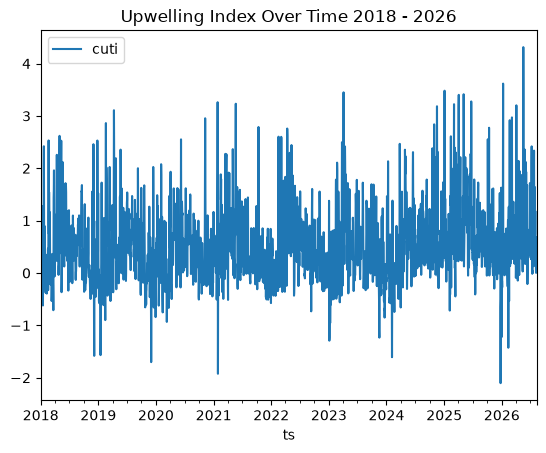

In [133]:
cuti_average_by_date.plot(x="ts", y="cuti", kind="line", title="Upwelling Index Over Time 2018 - 2026")

In [134]:
cuti["yq"] = cuti["ts"].dt.to_period("Q")
cuti_quarterly = cuti.groupby("yq")["cuti"].mean().reset_index()

<Axes: title={'center': 'Upwelling Index - quarterly Over Time 2018 - 2026'}, xlabel='yq'>

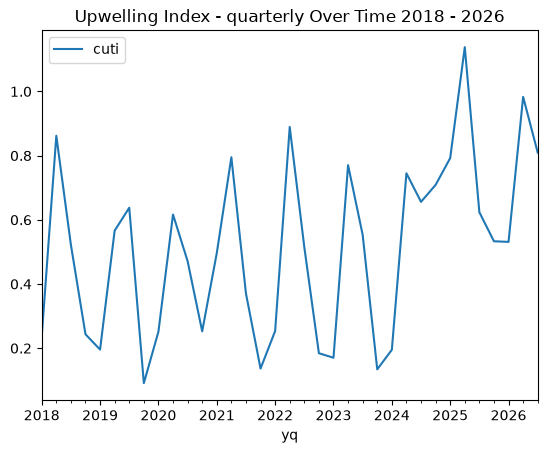

In [135]:
cuti_quarterly.plot(x="yq", y="cuti", kind="line", title="Upwelling Index - quarterly Over Time 2018 - 2026")

--- 
PDO - Pacific Decadal Ossilators

In [136]:
pdo

,date,pdo
0,1850-01-01,1.06
1,1850-02-01,-0.95
2,1850-03-01,-1.77
3,1850-04-01,-2.77
4,1850-05-01,-1.28
...,...,...
2112,2026-01-01,-0.87
2113,2026-02-01,-0.79
2114,2026-03-01,-1.18
2115,2026-04-01,-1.28


In [137]:

pdo["yq"] = pdo["date"].dt.to_period("Q")
pdo_quarterly = pdo.groupby("yq")["pdo"].mean().reset_index()

<Axes: title={'center': 'Pacific Decadal Oscillation - quarterly Over Time 2018 - 2026'}, xlabel='yq'>

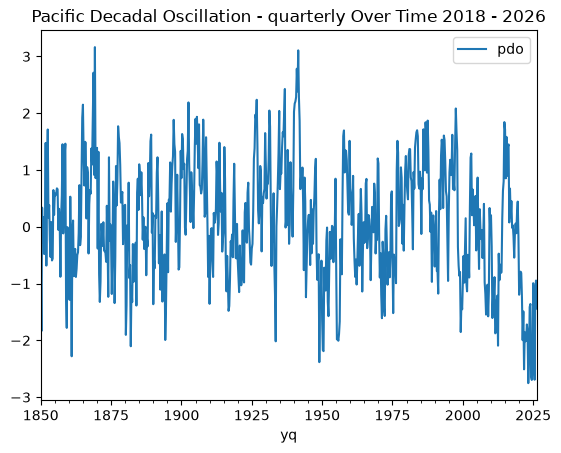

In [138]:
pdo_quarterly.plot(x="yq", y="pdo", kind="line", title="Pacific Decadal Oscillation - quarterly Over Time 2018 - 2026")

--- 
Glider 


In [139]:
glider

,mission,ts,lat,lon,depth,doxy,temperature,salinity,chl_glider
0,38,2015-03-23 06:02:55,34.256737,-120.508665,10.0,NaN,14.714667,33.320333,1.684429
1,38,2015-03-23 09:03:10,34.253740,-120.496205,10.0,NaN,14.875273,33.317182,1.399931
2,38,2015-03-23 12:04:15,34.249180,-120.478053,10.0,NaN,14.768300,33.317800,1.209480
3,38,2015-03-23 14:59:41,34.242535,-120.448037,10.0,NaN,14.752154,33.318385,1.109773
4,38,2015-03-23 17:49:01,34.234770,-120.419400,10.0,NaN,14.855364,33.318364,0.949979
...,...,...,...,...,...,...,...,...,...
256695,81,2026-06-16 12:33:11,34.338363,-119.741240,500.0,NaN,NaN,NaN,NaN
256696,81,2026-06-16 13:04:23,34.342015,-119.737317,500.0,NaN,NaN,NaN,NaN
256697,81,2026-06-16 13:38:19,34.346100,-119.733295,500.0,NaN,NaN,NaN,NaN
256698,81,2026-06-16 14:12:34,34.350068,-119.729817,500.0,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Dissolved Oxygen Over Time 2018 - 2026'}, xlabel='ts'>

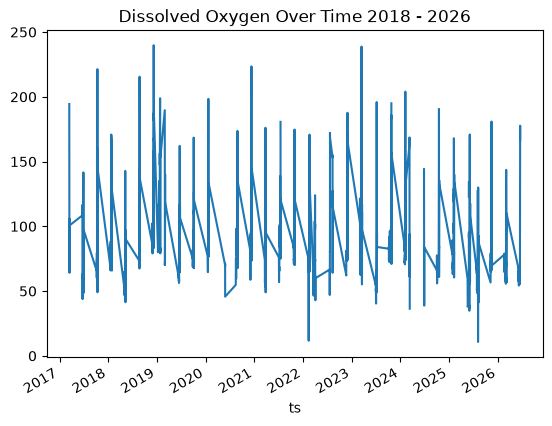

In [140]:
glider.groupby(['ts'])['doxy'].mean().plot(kind="line", title="Dissolved Oxygen Over Time 2018 - 2026")


<Axes: title={'center': 'Dissolved Oxygen with depth'}, xlabel='depth'>

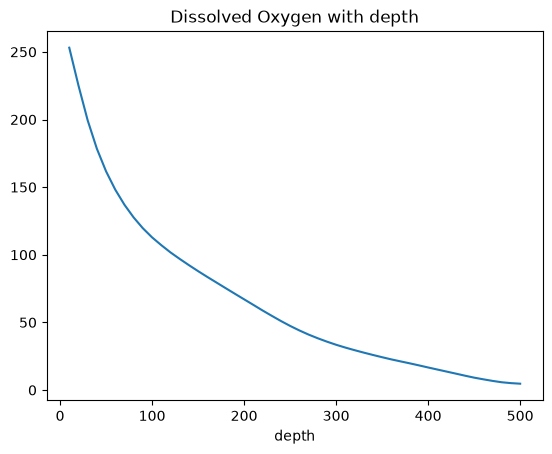

In [141]:
glider.groupby(['depth'])['doxy'].mean().plot(kind="line", title="Dissolved Oxygen with depth")

<Axes: title={'center': 'temperature Over Time 2018 - 2026'}, xlabel='ts'>

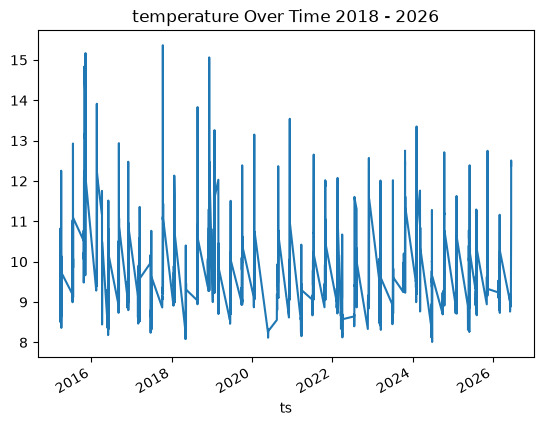

In [142]:
glider.groupby(['ts'])['temperature'].mean().plot(kind="line", title="temperature Over Time 2018 - 2026")

<Axes: title={'center': 'temperature with depth'}, xlabel='depth'>

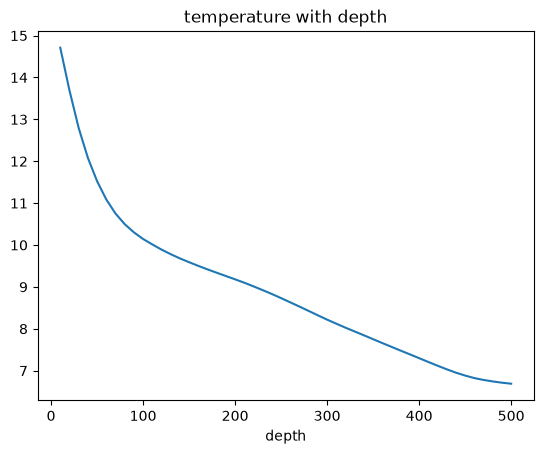

In [143]:
glider.groupby(['depth'])['temperature'].mean().plot(kind="line", title="temperature with depth")

<Axes: title={'center': 'Salinity Over Time 2018 - 2026'}, xlabel='ts'>

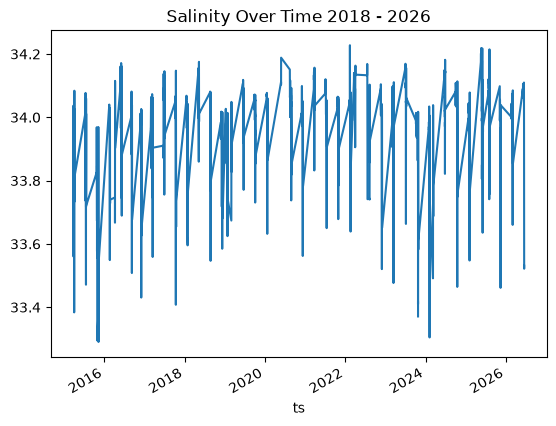

In [144]:
glider.groupby(['ts'])['salinity'].mean().plot(kind="line", title="Salinity Over Time 2018 - 2026")

<Axes: title={'center': 'chlorophyll Time 2018 - 2026'}, xlabel='ts'>

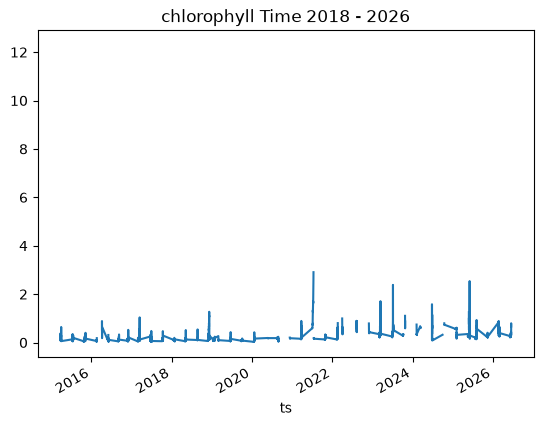

In [145]:
glider.groupby(['ts'])['chl_glider'].mean().plot(kind="line", title="chlorophyll Time 2018 - 2026")

<Axes: title={'center': 'Chlorophyll with depth'}, xlabel='depth'>

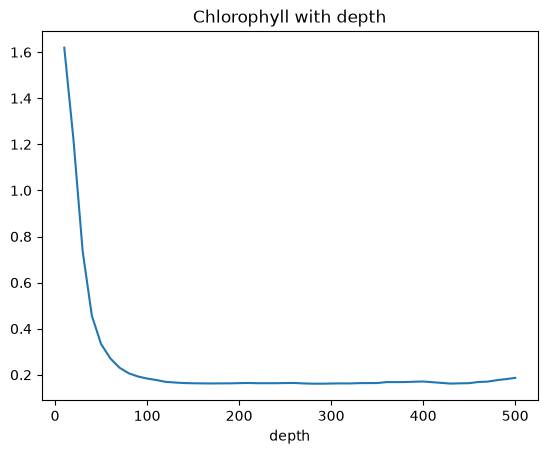

In [146]:
glider.groupby(['depth'])['chl_glider'].mean().plot(kind="line", title="Chlorophyll with depth")

<Axes: title={'center': 'Chlorophyll with depth'}, xlabel='doxy'>

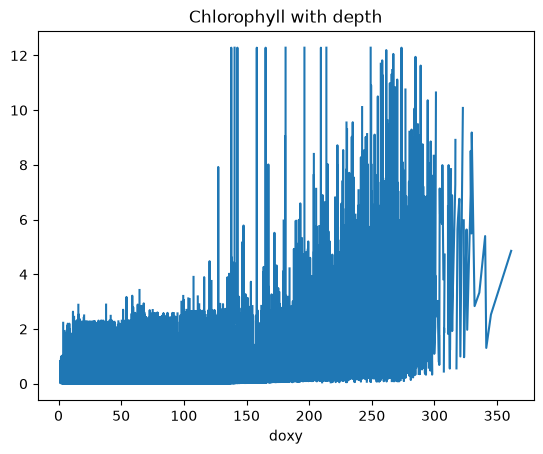

In [147]:
glider.groupby(['doxy'])['chl_glider'].mean().plot(kind="line", title="Chlorophyll with depth")

<Axes: title={'center': 'Chlorophyll with temperature'}, xlabel='temperature'>

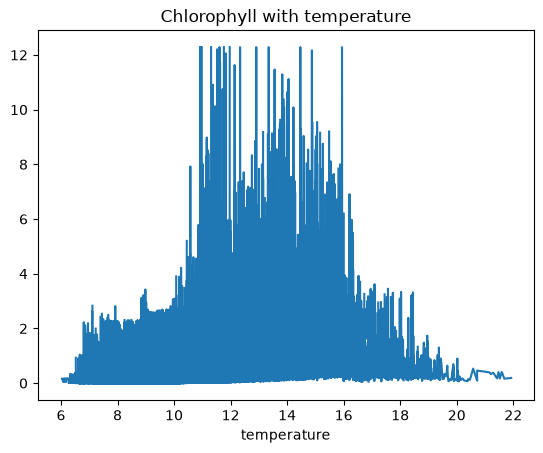

In [148]:
glider.groupby(['temperature'])['chl_glider'].mean().plot(kind="line", title="Chlorophyll with temperature")

<Axes: title={'center': 'Chlorophyll with Salinity'}, xlabel='salinity'>

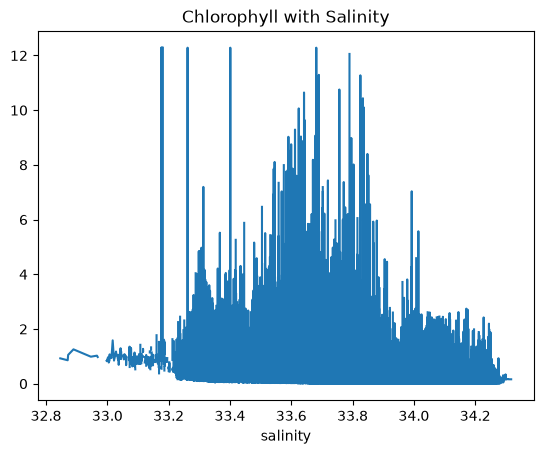

In [149]:
glider.groupby(['salinity'])['chl_glider'].mean().plot(kind="line", title="Chlorophyll with Salinity")

I want to explore and see if the variables have changed with time as well 


---
Kelp
* Giant Kelp (Macrocystis pyrifera)
* Elk Kelp (Pelagophycus porra)
* Bull Kelp (Nereocystis luetkeana)



In [150]:
kelp.head()

,date,pixel,lat,lon,biomass_kg,area_m2,passes,year,quarter
0,1984-02-15,164613,34.101798,-120.519864,NaN,NaN,0,1984,1
1,1984-02-15,164617,34.101807,-120.519540,NaN,NaN,0,1984,1
2,1984-02-15,164647,34.101043,-120.517883,NaN,NaN,0,1984,1
3,1984-02-15,164661,34.101323,-120.517570,NaN,NaN,0,1984,1
4,1984-02-15,166225,34.509919,-120.515074,NaN,NaN,0,1984,1


In [151]:
kelp_average_biomass_by_date = kelp.groupby(['date']).agg({'biomass_kg': 'mean'}).reset_index()

<Axes: title={'center': 'Average Kelp Biomass Over Time 1984 - 2026'}, xlabel='date'>

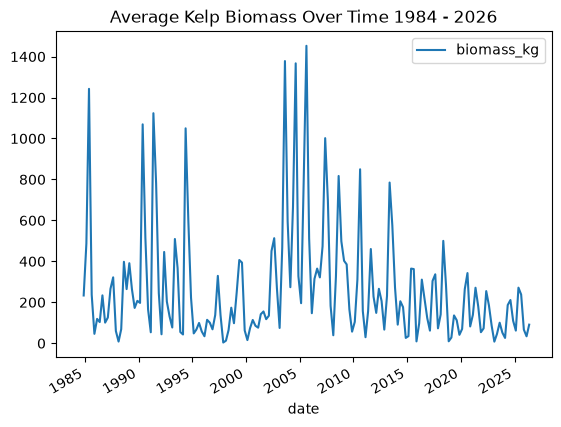

In [152]:
kelp_average_biomass_by_date.plot(x="date", y="biomass_kg", kind="line", title="Average Kelp Biomass Over Time 1984 - 2026")

In [153]:
kelp_average_area_by_date = kelp.groupby(['date']).agg({'area_m2': 'mean'}).reset_index()

<Axes: title={'center': 'Average Kelp Area Over Time 1984 - 2026'}, xlabel='date'>

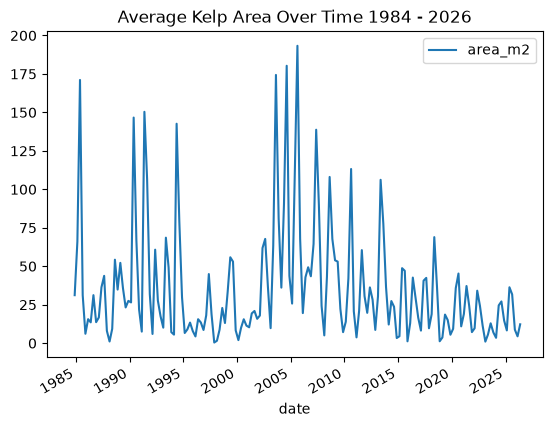

In [154]:
kelp_average_area_by_date.plot(x="date", y="area_m2", kind="line", title="Average Kelp Area Over Time 1984 - 2026")

Text(0, 0.5, 'Average Kelp Biomass and Area')

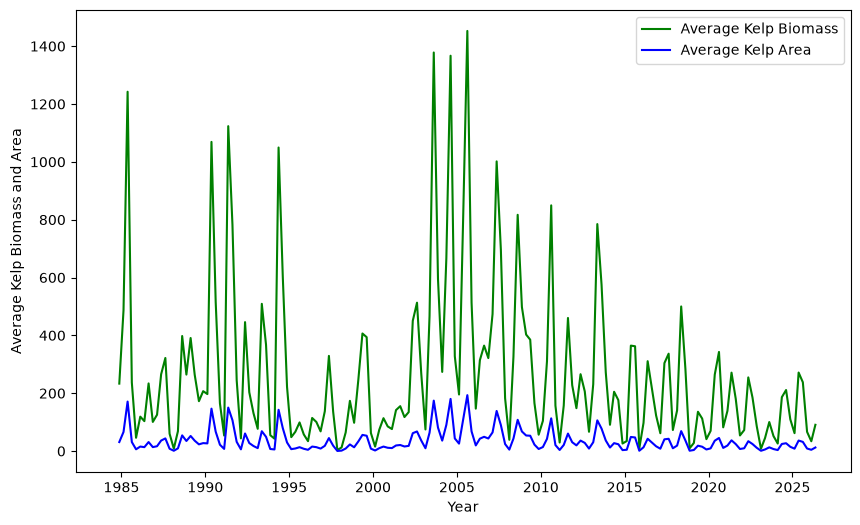

In [155]:
plt.figure(figsize=(10, 6))

plt.plot(kelp_average_biomass_by_date['date'], kelp_average_biomass_by_date['biomass_kg'], label='Average Kelp Biomass', color='green')
plt.plot(kelp_average_area_by_date['date'], kelp_average_area_by_date['area_m2'], label='Average Kelp Area', color='blue')

plt.legend()
plt.xlabel('Year')
plt.ylabel('Average Kelp Biomass and Area')

In [156]:
kelp_average_biomass_by_date["yq"] = kelp_average_biomass_by_date["date"].dt.to_period("Q")

Text(0, 0.5, 'Average Kelp Biomass and Sea Surface Temperature')

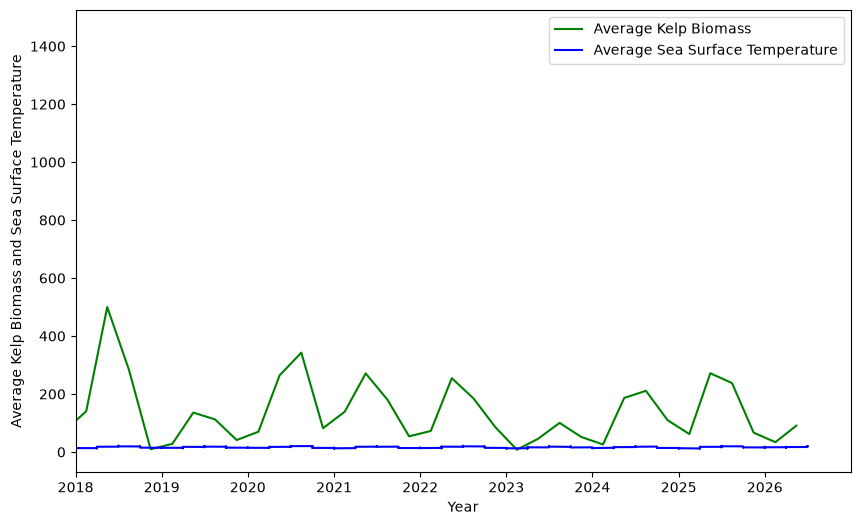

In [159]:
plt.figure(figsize=(10, 6))
#need to have them for the same as kelp spans from 1985 till 2026 but sst I only have from 2018 till 2026, so I will limit the x axis to 2018 till 2026
plt.xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-12-31"))

plt.plot(kelp_average_biomass_by_date['date'], kelp_average_biomass_by_date['biomass_kg'], label='Average Kelp Biomass', color='green')
plt.plot(sst_average_by_date['yq'].dt.to_timestamp(), sst_average_by_date['sst_c'], label='Average Sea Surface Temperature', color='blue')


plt.legend()
plt.xlabel('Year')
plt.ylabel('Average Kelp Biomass and Sea Surface Temperature')


Text(0, 0.5, 'Average Kelp Biomass and puple urchin density')

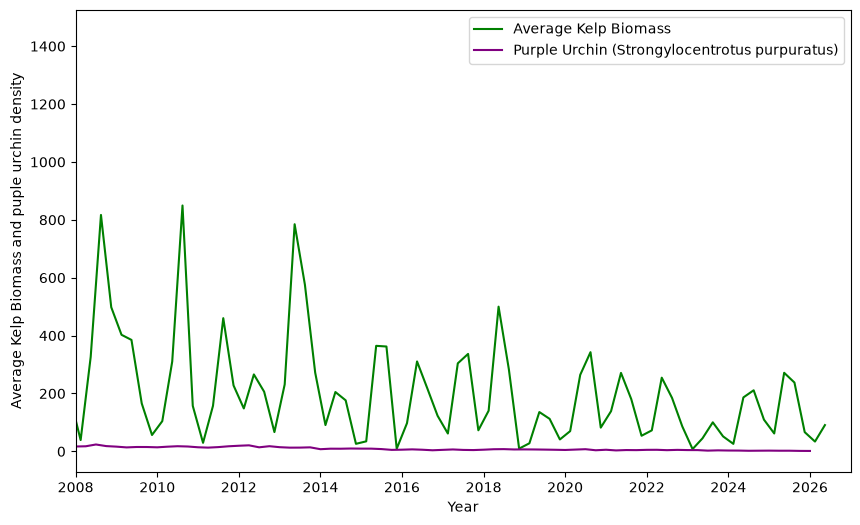

In [163]:
plt.figure(figsize=(10, 6))
#need to have them for the same as kelp spans from 1985 till 2026 but sst I only have from 2018 till 2026, so I will limit the x axis to 2018 till 2026
plt.xlim(pd.Timestamp("2008-01-01"), pd.Timestamp("2026-12-31"))

plt.plot(kelp_average_biomass_by_date['date'], kelp_average_biomass_by_date['biomass_kg'], label='Average Kelp Biomass', color='green')
plt.plot(purple_urchin["yq"].dt.to_timestamp(), purple_urchin["density"], label="Purple Urchin (Strongylocentrotus purpuratus)", color="purple")
plt.legend()
plt.xlabel('Year')
plt.ylabel('Average Kelp Biomass and puple urchin density')


---
let's see chlorophyll


In [158]:
chl_erd

,ts,lat,lon,chl_obs
0,2018-01-29 12:00:00,34.51125,-120.52125,NaN
1,2018-01-29 12:00:00,34.51125,-120.51375,NaN
2,2018-01-29 12:00:00,34.51125,-120.50625,NaN
3,2018-01-29 12:00:00,34.51125,-120.49875,NaN
4,2018-01-29 12:00:00,34.51125,-120.49125,NaN
...,...,...,...,...
60411967,2026-05-31 12:00:00,33.68625,-119.01375,0.225186
60411968,2026-05-31 12:00:00,33.68625,-119.00625,0.233748
60411969,2026-05-31 12:00:00,33.68625,-118.99875,0.246969
60411970,2026-05-31 12:00:00,33.68625,-118.99125,0.246969
